In [321]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, integrate

%precision 3

'%.3f'

In [322]:
!ls ./drive/MyDrive/data/*csv

./drive/MyDrive/data/air-passengers.csv
./drive/MyDrive/data/auto-mpg.csv
./drive/MyDrive/data/CCTV_Seoul.csv
./drive/MyDrive/data/ch11_potato.csv
./drive/MyDrive/data/ch2_scores_em.csv
./drive/MyDrive/data/ch4_scores400.csv
./drive/MyDrive/data/matplotlib_plot_data.csv
./drive/MyDrive/data/seoul_cctv.csv
./drive/MyDrive/data/stock-data.csv
./drive/MyDrive/data/stock_name_code_ChangePrice.csv
./drive/MyDrive/data/stock_px_2.csv


In [323]:
df = pd.read_csv('./drive/MyDrive/data/ch4_scores400.csv')

In [324]:
df

,score
0,76
1,55
2,80
3,80
4,74
...,...
395,77
396,60
397,83
398,80


In [325]:
scores = np.array(df['score'])

In [326]:
scores

array([ 76,  55,  80,  80,  74,  61,  81,  76,  23,  80,  41,  80,  68,
        88,  69,  57,  68,  86,  70,  68,  81,  73,  70,  90,  93,  79,
        66,  92,  88,  81,  52,  72,  59,  68,  74,  72,  63,  89,  45,
        81,  42,  76,  57,  83,  71,  74,  55,  60,  73,  79, 100,  73,
        85,  47,  50,  65,  52,  92,  64,  91,  92,  71,  78,  69,  78,
        77,  68,  78,  96,  81,  75,  72,  55,  55,  75,  49,  59,  89,
        99,  45,  94,  67,  70,  68,  86,  46,  77,  56,  79,  93,  70,
        76,  76,  58,  93,  96,  81,  71,  63,  61,  96,  91,  69,  46,
        28,  54,  68,  91,  60,  78,  90,  72,  68,  50,  52,  76,  67,
        72,  69,  80,  58,  65,  98,  58,  66,  61,  77,  85,  63,  64,
        66,  78,  59,  64,  34,  49,  68,  83,  74,  54,  49,  73,  45,
        86,  71,  46,  56,  59,  58,  48,  57,  60,  59,  87,  72,  55,
        65,  57,  65,  83,  74, 100,  76,  56,  82,  86,  86,  54,  68,
        87,  45,  63,  49,  56,  55,  89,  66,  57,  54,  72,  7

# 모평균, 모분산 산출

In [327]:
# 모평균
p_mean = np.mean(scores)
# 모분산
p_var = np.var(scores)

In [328]:
p_mean, p_var

(np.float64(69.53), np.float64(206.6691))

표본크기 20개인

In [329]:
np.random.seed(0)
n = 20
sample = np.random.choice(scores, n)
sample

array([49, 60, 72, 86, 52, 61, 77, 91, 80, 56, 69, 67, 90, 56, 75, 79, 60,
       79, 68, 81])

In [330]:
np.random.seed(1111)
n_samples = 10000
samples = np.random.choice(scores, (n_samples, n))
samples

array([[ 68,  75,  91, ...,  72,  57,  59],
       [ 97,  55,  61, ...,  65,  73,  71],
       [ 78,  67,  43, ...,  76,  62,  71],
       ...,
       [ 72,  87,  84, ...,  65,  59,  87],
       [ 54,  74,  69, ...,  69,  97,  72],
       [ 78,  57,  85, ...,  68, 100,  94]])

In [331]:
s_mean = np.mean(sample)

In [332]:
s_mean

np.float64(70.4)

In [333]:
sample_means = np.mean(samples, axis=1)
np.mean(sample_means)

np.float64(69.53799999999998)

In [334]:
samples.shape

(10000, 20)

In [335]:
sample_vars = np.var(samples, axis=1)
np.mean(sample_vars)

np.float64(196.34417850000003)

불편분산 계산

In [336]:
# 불편분산 계산
sample_u_vars = np.var(samples, axis=1, ddof=1)
np.mean(sample_u_vars)

np.float64(206.67808263157895)

In [337]:
u_var = np.var(sample, ddof=1)

표본평균 $\bar{X}$와 $s^2$은 모평균과 모분산의 불편추정량이다.

# 구간추정
1. 모평균 추정, 모분산을 알고 있는 경우 --> 표본평균 이용

$$
\bar{X} \sim N (\mu, \frac{\sigma^2}{n})
$$
<br>
<br>
$$
Z = \frac{(\bar{X} - \mu)}{\sqrt{\frac{\sigma^2}{n}}} \ \sim \  N(0, 1)
$$

# 표준오차
$$\sqrt{\frac{\sigma^2}{n}}$$

상위 100 $a\%$점

$a = 0.05$
<br>
$$
\chi_{0.05}^2(5)
\\
Z_{a}
$$

In [338]:
rv = stats.norm()
lcl = s_mean - rv.isf(0.025) * np.sqrt(p_var/n)
ucl = s_mean - rv.isf(0.975) * np.sqrt(p_var/n)

In [339]:
lcl, ucl # 모평균 신뢰구간

(np.float64(64.09956018535247), np.float64(76.70043981464754))

In [340]:
p_mean, p_var, n, s_mean

(np.float64(69.53), np.float64(206.6691), 20, np.float64(70.4))

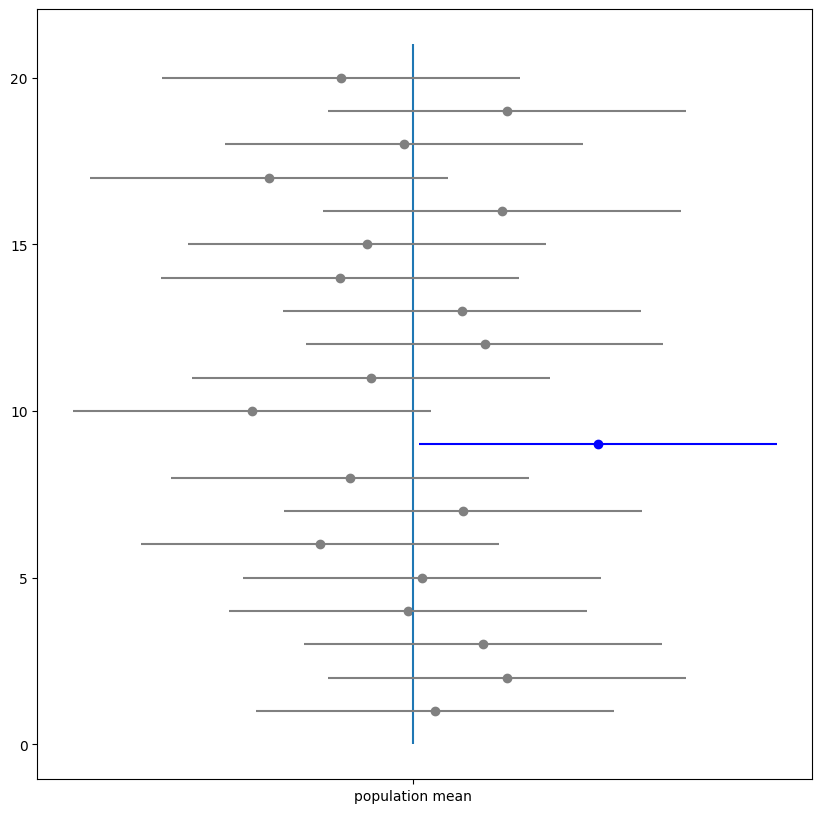

In [341]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)

rv = stats.norm()
n_samples = 20
ax.vlines(p_mean, 0, 21)
for i in range(n_samples):
    sample_ = samples[i]
    s_mean_ = np.mean(sample_)
    lcl = s_mean_ - rv.isf(0.025) * np.sqrt(p_var/n)
    ucl = s_mean_ - rv.isf(0.975) * np.sqrt(p_var/n)
    if lcl <= p_mean <= ucl:
        ax.scatter(s_mean_, n_samples-i, color='gray')
        ax.hlines(n_samples-i, lcl, ucl, color='gray')
    else:
        ax.scatter(s_mean_, n_samples-i, color='b')
        ax.hlines(n_samples-i, lcl, ucl, color='b')

ax.set_xticks([p_mean])
ax.set_xticklabels(['population mean'])
plt.show()

In [342]:
rv = stats.norm()
cnt = 0

for sample_ in samples:
    s_mean_ = np.mean(sample_)
    lcl = s_mean_ - rv.isf(0.025) * np.sqrt(p_var/n)
    ucl = s_mean_ - rv.isf(0.975) * np.sqrt(p_var/n)
    if lcl <= p_mean <= ucl:
        cnt += 1

print(cnt/len(samples))

0.9512


# 모분산의 신뢰구간

In [343]:
rv = stats.chi2(df=n-1)
cnt = 0

for sample_ in samples:
    u_var_ = np.var(sample_, ddof=1)
    lcl = (n-1) * u_var_ / rv.isf(0.025)
    ucl = (n-1) * u_var_ / rv.isf(0.975)
    if lcl <= p_var <= ucl:
        cnt += 1

print(cnt/len(samples))

0.9641


[
$
\bar{X} - z_{a/2} \sqrt{\frac{\sigma^2}{n}}
$
,
$
\bar{X} - z_{1-a/2} \sqrt{\frac{\sigma^2}{n}}
$
]

In [344]:
n, s_mean, u_var

(20, np.float64(70.4), np.float64(158.25263157894742))

In [345]:
rv = stats.t(df=n-1)
lcl = s_mean - rv.isf(0.025) * np.sqrt(u_var/n)
ucl = s_mean - rv.isf(0.975) * np.sqrt(u_var/n)
lcl, ucl

(np.float64(64.51244886603887), np.float64(76.28755113396114))

# 통계적 가설검정

모집단의 모수에 관한 가설을 세우고 표본의 정보를 이용해 그 가설을 검증하는 것

In [346]:
!ls ./drive/MyDrive/data/*csv

./drive/MyDrive/data/air-passengers.csv
./drive/MyDrive/data/auto-mpg.csv
./drive/MyDrive/data/CCTV_Seoul.csv
./drive/MyDrive/data/ch11_potato.csv
./drive/MyDrive/data/ch2_scores_em.csv
./drive/MyDrive/data/ch4_scores400.csv
./drive/MyDrive/data/matplotlib_plot_data.csv
./drive/MyDrive/data/seoul_cctv.csv
./drive/MyDrive/data/stock-data.csv
./drive/MyDrive/data/stock_name_code_ChangePrice.csv
./drive/MyDrive/data/stock_px_2.csv


In [347]:
df = pd.read_csv('./drive/MyDrive/data/ch11_potato.csv')

In [348]:
df

,무게
0,122.02
1,131.73
2,130.60
3,131.82
4,132.05
5,126.12
6,124.43
7,132.89
8,122.79
9,129.95


In [349]:
sample = np.array(df['무게'])
sample

array([122.02, 131.73, 130.6 , 131.82, 132.05, 126.12, 124.43, 132.89,
       122.79, 129.95, 126.14, 134.45, 127.64, 125.68])

In [350]:
s_mean = np.mean(sample)
s_mean

np.float64(128.4507142857143)

모평균 = 130, 분산 = 9

$X_1, X_2, X_3,...X_{14} \sim N(130, 9)$

$$ \bar{X} \sim N(130, \frac{9}{14})$$

128.45g 이어서 --> 모평균 130이 아니라 그보다 적다라는 주장을 하고 싶음.

$$
P(\bar{X} \le x) = 0.05
$$

In [351]:
rv = stats.norm(130, np.sqrt(9/14))
rv.isf(0.85)

np.float64(129.16900457549315)

In [352]:
rv.cdf(s_mean)

np.float64(0.026661319523126635)

통계적 가설 검정 순서

1. 모집단의 모수에 관하여 두가지 가설을 세우기
    
- 귀무가설 ($H_0$) : 모평균은 130이다.

    검증하는 사람이 기각하려는 가설

- 대립가설 ($H_1$) : 모평균이 130보다 작다.
    
    검증하는 사람이 채택하려는 가설

- 대립가설 채택 = 귀무가설 기각

- 대립가설 미채택 = 귀무가설 수용

2. 표본으로 부터 계산되는 통계량을 이용
3. 어느 가설이 옳은지 통계적인 방법으로 판단

귀무가설의 기각 조건

1. 검정 통계량으로 판단 : 표본으로 부터 구한 통계량이 기각역 안에 있다.

2. 확률로 판단 : p-value < $\alpha$ (유의수준)

p-value : 귀무가설에 의한 검정통계량의 확률

$\alpha$ (유의수준) : 오류가 발생할 최대 허용 확률

In [353]:
rv.isf(0.95)

np.float64(128.68118313069039)

In [354]:
s_mean

np.float64(128.4507142857143)

In [355]:
s_mean < rv.isf(0.95)

np.True_

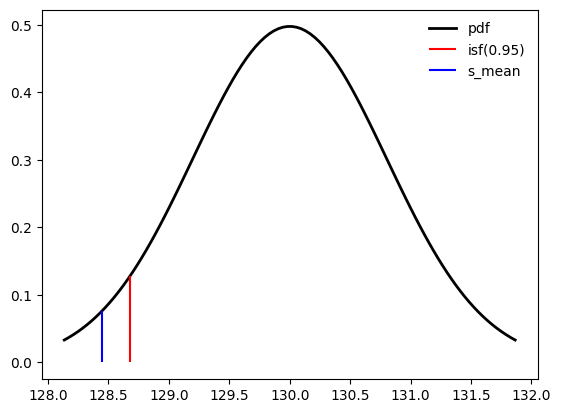

In [356]:
xs=np.linspace(rv.ppf(0.01), rv.ppf(0.99), 100)
plt.plot(xs, rv.pdf(xs), 'k-', lw=2, label='pdf')
plt.vlines(rv.isf(0.95),0, rv.pdf(rv.isf(0.95)), color='r', label='isf(0.95)')
plt.vlines(s_mean, 0, rv.pdf(s_mean), color='b',
           label='s_mean')
plt.legend(loc='best', frameon=False)
plt.show()

s_mean < 임계값 이므로 귀무가설 기각
<br>
<br>
Z를 사용할 경우

In [357]:
z = (s_mean - 130) / np.sqrt(9/14)

In [358]:
z

np.float64(-1.932298779026813)

In [359]:
rv = stats.norm()
rv.isf(0.95)

np.float64(-1.6448536269514722)

In [360]:
-1.93 < -1.64

True

p-value 를 이용한 검증

In [361]:
rv.cdf(z) # p-value

np.float64(0.026661319523126635)

In [362]:
0.02 < 0.05

True

h0 : 130
h1 : 130 보다 작다

h1 : 130이 아니다 => 양쪽 다 검증 해야함

양측검증 : 130 보다 큰경우도 고려하기

In [363]:
rv = stats.norm(130, np.sqrt(9/14))

In [364]:
rv_interval = rv.interval(0.95)

In [365]:
s_mean

np.float64(128.4507142857143)

In [366]:
# 기각 부분에 있는지 채택 부분에 있는지
rv_interval[0] <= s_mean <= rv_interval[1] # True --> 채택역 안에있다

np.True_

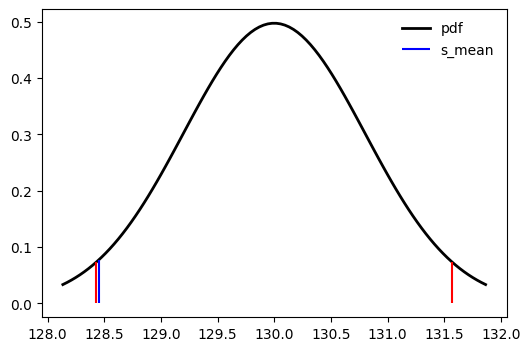

In [367]:
plt.figure(figsize=(6, 4))
xs=np.linspace(rv.ppf(0.01), rv.ppf(0.99), 100)
plt.plot(xs, rv.pdf(xs), 'k-', lw=2, label='pdf')
plt.vlines(rv_interval[0], 0, rv.pdf(rv_interval[0]), color='r')
plt.vlines(rv_interval[1], 0, rv.pdf(rv_interval[1]), color='r')
plt.vlines(s_mean, 0, rv.pdf(s_mean), color='b',
           label='s_mean')
plt.legend(loc='best', frameon=False)
plt.show()

Z를 사용한 양측 검정

In [368]:
z = (s_mean - 130) / np.sqrt(9/14)
z

np.float64(-1.932298779026813)

In [369]:
rv = stats.norm()
rv_itv = rv.interval(0.95)
rv_itv

(np.float64(-1.959963984540054), np.float64(1.959963984540054))

In [370]:
rv_itv[0] <= z <= rv_itv[1]

np.True_

귀무가설을 기각 할 수 없다.

p-value를 이용한 양측검증

In [371]:
# p-value
rv.cdf(z) * 2

np.float64(0.05332263904625327)

양측검증 일 때

p-value > 유의수준 --> 귀무가설을 기각할 수 없다.

0.053 > 0.05 --> 귀무가설을 기각할 수 없다.

제 1종 오류 : 귀무가설이 옳을 때, 귀무가설을 기각하는 오류

제 2종 오류 : 대립가설이 옳을 때, 귀무가설을 채택하는 오류

In [372]:
rv = stats.norm(130, 3)

In [380]:
c = stats.norm().isf(0.95) # 표준정규분포
n_samples = 10000
cnt = 0

for i in range(n_samples):
    sample_ = np.round(rv.rvs(14), 2) # 14개 씩 추출, 소수점 2자리까지 반올림
    s_mean_ = np.mean(sample_)
    z = (s_mean_ - 130) / np.sqrt(9/14) # 표본
    if z < c:
        cnt += 1

In [381]:
cnt / n_samples

0.052

# Numpy
https://github.com/numpy/numpy

1-D array

In [383]:
arr = np.array([1, 2, 3, 4, 5])
print(arr)
print(type(arr))

[1 2 3 4 5]
<class 'numpy.ndarray'>


In [388]:
arr

array([1, 2, 3, 4, 5])

In [389]:
att = arr.T

In [390]:
arr.shape

(5,)

In [393]:
# 차원수 보기 ndim
arr.ndim

1

shape : 배열의 각 차원의 크기(튜플 형식)

In [394]:
att.shape

(5,)

In [395]:
att.ndim

1

In [396]:
arr

array([1, 2, 3, 4, 5])

In [399]:
arr.reshape(5, 1).shape

(5, 1)

In [402]:
arr.reshape(1, 5)

array([[1, 2, 3, 4, 5]])

In [403]:
arr.reshape(1, 5).ndim

2

2-D, 3-D array

In [404]:
arr = np.array([[10, 20, 30], [-1, -2, -3]])

In [405]:
arr.ndim

2

In [406]:
arr

array([[10, 20, 30],
       [-1, -2, -3]])

In [407]:
arr.shape

(2, 3)

In [408]:
arr.T

array([[10, -1],
       [20, -2],
       [30, -3]])

In [409]:
arr.T.shape

(3, 2)

In [414]:
arr

array([[10, 20, 30],
       [-1, -2, -3]])

In [415]:
arr[1, 2]

np.int64(-3)

In [416]:
arr[0, 2]

np.int64(30)

In [417]:
arr.T[2, 0]

np.int64(30)

In [418]:
arr[0, 0], arr[1, 1]

(np.int64(10), np.int64(-2))

In [419]:
arr.T[0, 0], arr.T[1, 1]

(np.int64(10), np.int64(-2))

In [420]:
brr = np.array([[[10, 20, 30], [-1, -2, -3]], [[1, 2, 3], [11, 21, 31]]])

In [421]:
brr.shape, brr.ndim

((2, 2, 3), 3)

In [422]:
brr

array([[[10, 20, 30],
        [-1, -2, -3]],

       [[ 1,  2,  3],
        [11, 21, 31]]])

In [425]:
brr[1][0][2]

np.int64(3)

In [430]:
a = np.array(42)

In [431]:
a.shape, a.ndim

((), 0)

In [432]:
a = np.array([42, 45])

In [433]:
a.ndim, a.shape

(1, (2,))

In [435]:
arr = np.array([1, 2, 3, 4], ndmin=6)

In [451]:
arr.shape, arr.ndim

((1, 1, 1, 1, 1, 4), 6)

In [455]:
arr2 = np.array([[[1, 2, 3], [4, 5, 6]],[[7,8,9],[10,11,12]]])

In [456]:
arr2.reshape(2, -1)

array([[ 1,  2,  3,  4,  5,  6],
       [ 7,  8,  9, 10, 11, 12]])

In [457]:
arr2.reshape(3, -1)

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [458]:
arr2.reshape(-1, 4)

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [459]:
np.arange(13)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [460]:
np.arange(1, 13)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [461]:
np.arange(1, 13, 2)

array([ 1,  3,  5,  7,  9, 11])

In [462]:
np.arange(1, 13).reshape(-1, 3)

array([[ 1,  2,  3],
       [ 4,  5,  6],
       [ 7,  8,  9],
       [10, 11, 12]])

In [463]:
brr = np.arange(12).reshape(2, -1, 1)

In [466]:
brr.shape

(2, 6, 1)

In [472]:
arr = np.array([1.2, 0.2, -3.4])

In [473]:
arr.astype(int)

array([ 1,  0, -3])